# CNN para Classificação de Imagens — CIFAR-10

Implementação e treinamento de uma **Rede Neural Convolucional (CNN)** para classificação de objetos em imagens usando o dataset CIFAR-10.

O CIFAR-10 contém **60.000 imagens coloridas** (32×32 pixels) divididas em **10 classes**:
`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Verificar se GPU está disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo utilizado: cuda
GPU: NVIDIA GeForce RTX 4070


## 1. Carregamento dos Dados

Os arquivos do CIFAR-10 estão no formato pickle (binário). São 5 batches de treino + 1 batch de teste.

In [2]:
CIFAR_DIR = r"CIFAR-10 DATASET"

CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

def load_batch(filepath):
    """Carrega um batch do CIFAR-10 (formato pickle)."""
    with open(filepath, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    images = batch[b'data'].reshape(-1, 3, 32, 32).astype(np.float32)
    labels = np.array(batch[b'labels'])
    return images, labels

# Carrega os 5 batches de treino
X_train_list, y_train_list = [], []
for i in range(1, 6):
    path = os.path.join(CIFAR_DIR, f"data_batch_{i}")
    imgs, lbls = load_batch(path)
    X_train_list.append(imgs)
    y_train_list.append(lbls)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

# Carrega o batch de teste
X_test, y_test = load_batch(os.path.join(CIFAR_DIR, "test_batch"))

print(f"Treino  — Imagens: {X_train.shape}, Rótulos: {y_train.shape}")
print(f"Teste   — Imagens: {X_test.shape},  Rótulos: {y_test.shape}")
print(f"Classes: {CLASSES}")
print(f"Distribuição das classes (treino): {Counter(y_train)}")

C:\Users\Douglas Veras\AppData\Local\Temp\ipykernel_3632\1501457933.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding='bytes')


Treino  — Imagens: (50000, 3, 32, 32), Rótulos: (50000,)
Teste   — Imagens: (10000, 3, 32, 32),  Rótulos: (10000,)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Distribuição das classes (treino): Counter({np.int64(6): 5000, np.int64(9): 5000, np.int64(4): 5000, np.int64(1): 5000, np.int64(2): 5000, np.int64(7): 5000, np.int64(8): 5000, np.int64(3): 5000, np.int64(5): 5000, np.int64(0): 5000})


## 2. Visualização dos Dados

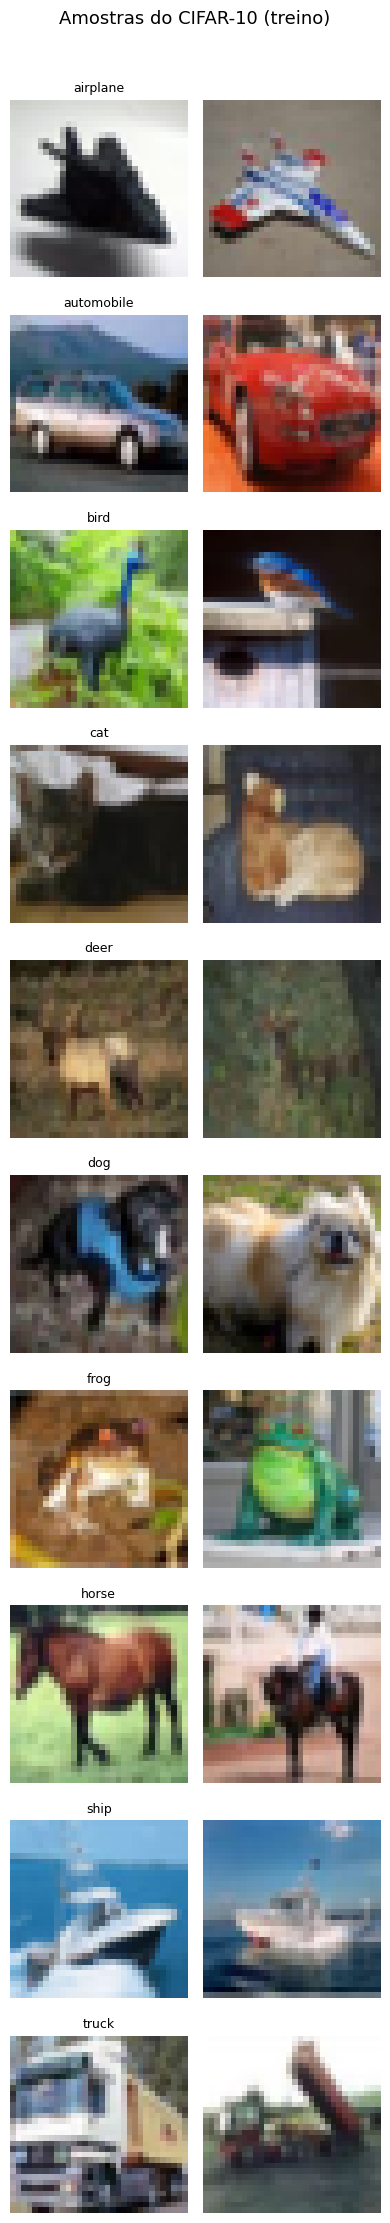

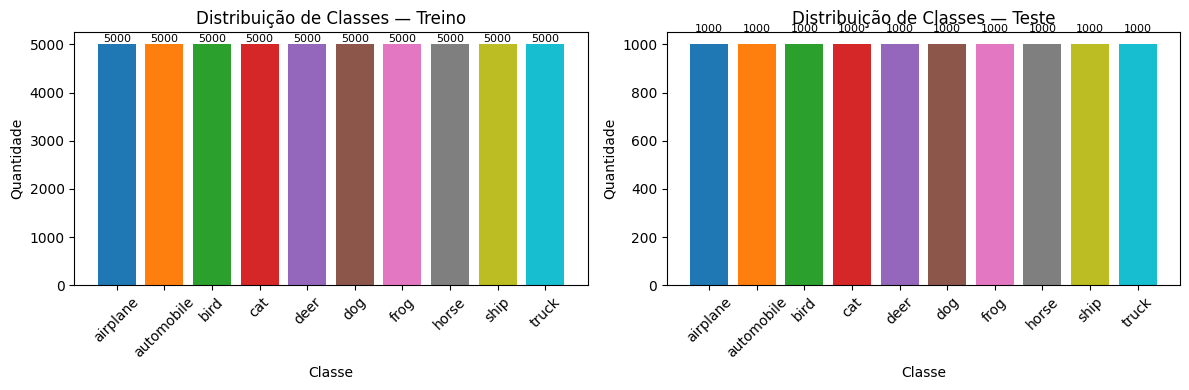

In [3]:
def imshow(img_chw, ax, title=""):
    """Exibe imagem no formato (C, H, W) na escala [0,255]."""
    img = img_chw.transpose(1, 2, 0).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Mostra 2 amostras de cada classe
fig, axes = plt.subplots(10, 2, figsize=(4, 22))
fig.suptitle("Amostras do CIFAR-10 (treino)", fontsize=13, y=1.01)

for cls_idx, cls_name in enumerate(CLASSES):
    indices = np.where(y_train == cls_idx)[0][:2]
    for col, idx in enumerate(indices):
        imshow(X_train[idx], axes[cls_idx][col],
               title=cls_name if col == 0 else "")

plt.tight_layout()
plt.show()

# Distribuição das classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (split_name, labels) in zip(axes, [("Treino", y_train), ("Teste", y_test)]):
    counts = [np.sum(labels == i) for i in range(10)]
    bars = ax.bar(CLASSES, counts, color=plt.cm.tab10.colors)
    ax.set_title(f"Distribuição de Classes — {split_name}")
    ax.set_xlabel("Classe")
    ax.set_ylabel("Quantidade")
    ax.tick_params(axis='x', rotation=45)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(count), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Pré-processamento

Normalização com média e desvio padrão calculados sobre o conjunto de treino (por canal RGB).
Os arrays são convertidos em tensores PyTorch e carregados via `DataLoader`.

In [4]:
# Normalização: valores [0,255] → divisão por 255, depois z-score por canal
X_train_f = X_train / 255.0
X_test_f  = X_test  / 255.0

# Média e desvio padrão calculados apenas no treino (eixos N, H, W)
mean = X_train_f.mean(axis=(0, 2, 3), keepdims=True)
std  = X_train_f.std(axis=(0, 2, 3),  keepdims=True)

X_train_norm = (X_train_f - mean) / std
X_test_norm  = (X_test_f  - mean) / std

print(f"Média por canal  (treino): {mean.flatten().round(4)}")
print(f"Desvio por canal (treino): {std.flatten().round(4)}")

# Tensores PyTorch
X_tr = torch.tensor(X_train_norm, dtype=torch.float32)
y_tr = torch.tensor(y_train,      dtype=torch.long)
X_te = torch.tensor(X_test_norm,  dtype=torch.float32)
y_te = torch.tensor(y_test,       dtype=torch.long)

BATCH_SIZE = 128

train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(TensorDataset(X_te, y_te),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nBatches de treino : {len(train_loader)}")
print(f"Batches de teste  : {len(test_loader)}")

Média por canal  (treino): [0.4914 0.4822 0.4465]
Desvio por canal (treino): [0.247  0.2435 0.2616]

Batches de treino : 391
Batches de teste  : 79


## 4. Arquitetura da CNN

A rede possui **3 blocos convolucionais** (Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout) seguidos de um **classificador totalmente conectado**.

| Bloco | Filtros | Tamanho saída |
|-------|---------|--------------|
| Conv1 | 32 → 64 | 8 × 8        |
| Conv2 | 64 → 128| 4 × 4        |
| Conv3 | 128 → 256| 2 × 2       |
| FC    | 1024 → 512 → 10 | — |

In [5]:
class CIFAR10_CNN(nn.Module):
    """
    CNN com 3 blocos convolucionais + cabeça classificadora totalmente conectada.
    Entrada: (N, 3, 32, 32)
    Saída  : (N, 10)  — logits
    """

    def __init__(self):
        super().__init__()

        # -------- Bloco 1: 3 → 32 → 64 canais | 32×32 → 16×16 --------
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # → 16×16
            nn.Dropout2d(0.25),
        )

        # -------- Bloco 2: 64 → 128 canais | 16×16 → 8×8 --------
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # → 8×8
            nn.Dropout2d(0.25),
        )

        # -------- Bloco 3: 128 → 256 canais | 8×8 → 4×4 --------
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # → 4×4
            nn.Dropout2d(0.25),
        )

        # -------- Classificador FC --------
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)


# Instanciar e inspecionar
model = CIFAR10_CNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParâmetros totais    : {total_params:,}")
print(f"Parâmetros treináveis: {trainable_params:,}")

CIFAR10_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, str

## 5. Treinamento

- **Otimizador**: Adam com learning rate inicial 1e-3  
- **Scheduler**: ReduceLROnPlateau (reduz LR quando a perda de validação estagna)  
- **Loss**: Cross-Entropy  
- **Épocas**: 30

In [6]:
EPOCHS    = 30
LR        = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                  factor=0.5, patience=3)

# ── Funções auxiliares ──────────────────────────────────────────────────────

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


# ── Loop de treinamento ─────────────────────────────────────────────────────

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"{'Época':>5} | {'Loss Treino':>11} | {'Acc Treino':>10} | "
      f"{'Loss Val':>8} | {'Acc Val':>7} | {'LR':>10}")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(test_loader,  train=False)
    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:>5} | {t_loss:>11.4f} | {t_acc*100:>9.2f}% | "
          f"{v_loss:>8.4f} | {v_acc*100:>6.2f}% | {current_lr:.2e}")

print("\nTreinamento concluído!")

Época | Loss Treino | Acc Treino | Loss Val | Acc Val |         LR
-----------------------------------------------------------------
    1 |      1.7012 |     36.48% |   1.3289 |  49.89% | 1.00e-03
    2 |      1.3321 |     51.98% |   1.0935 |  62.36% | 1.00e-03
    3 |      1.1461 |     59.48% |   0.9694 |  65.95% | 1.00e-03
    4 |      1.0246 |     64.27% |   0.8267 |  71.95% | 1.00e-03
    5 |      0.9188 |     68.58% |   0.7490 |  74.23% | 1.00e-03
    6 |      0.8370 |     71.55% |   0.7118 |  75.21% | 1.00e-03
    7 |      0.7743 |     73.79% |   0.6313 |  78.89% | 1.00e-03
    8 |      0.7083 |     76.40% |   0.6190 |  79.39% | 1.00e-03
    9 |      0.6510 |     78.16% |   0.5861 |  80.36% | 1.00e-03
   10 |      0.6085 |     79.66% |   0.5502 |  81.31% | 1.00e-03
   11 |      0.5720 |     80.82% |   0.5512 |  81.30% | 1.00e-03
   12 |      0.5243 |     82.46% |   0.5017 |  83.17% | 1.00e-03
   13 |      0.4973 |     83.46% |   0.4863 |  83.99% | 1.00e-03
   14 |      0.4654 | 

## 6. Curvas de Aprendizado

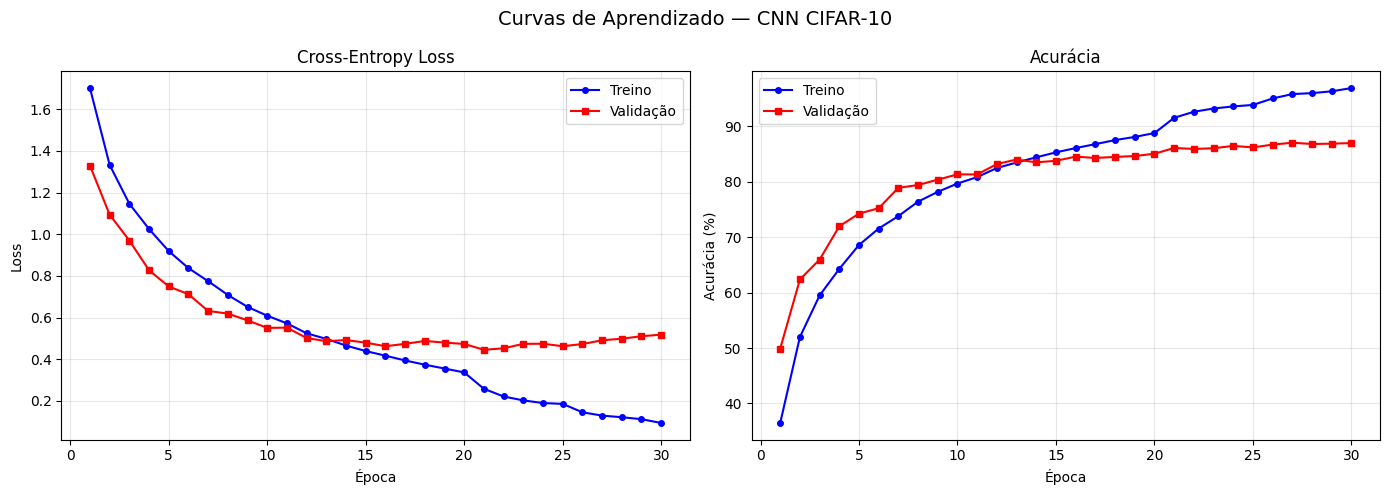

Melhor acurácia de validação: 87.02% (época 27)


In [7]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de Aprendizado — CNN CIFAR-10", fontsize=14)

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Treino')
ax1.plot(epochs_range, history['val_loss'],   'r-s', markersize=4, label='Validação')
ax1.set_title("Cross-Entropy Loss")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', markersize=4, label='Treino')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-s', markersize=4, label='Validação')
ax2.set_title("Acurácia")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val_acc = max(history['val_acc'])
best_epoch   = history['val_acc'].index(best_val_acc) + 1
print(f"Melhor acurácia de validação: {best_val_acc*100:.2f}% (época {best_epoch})")

## 7. Avaliação no Conjunto de Teste

Matriz de confusão e acurácia por classe.

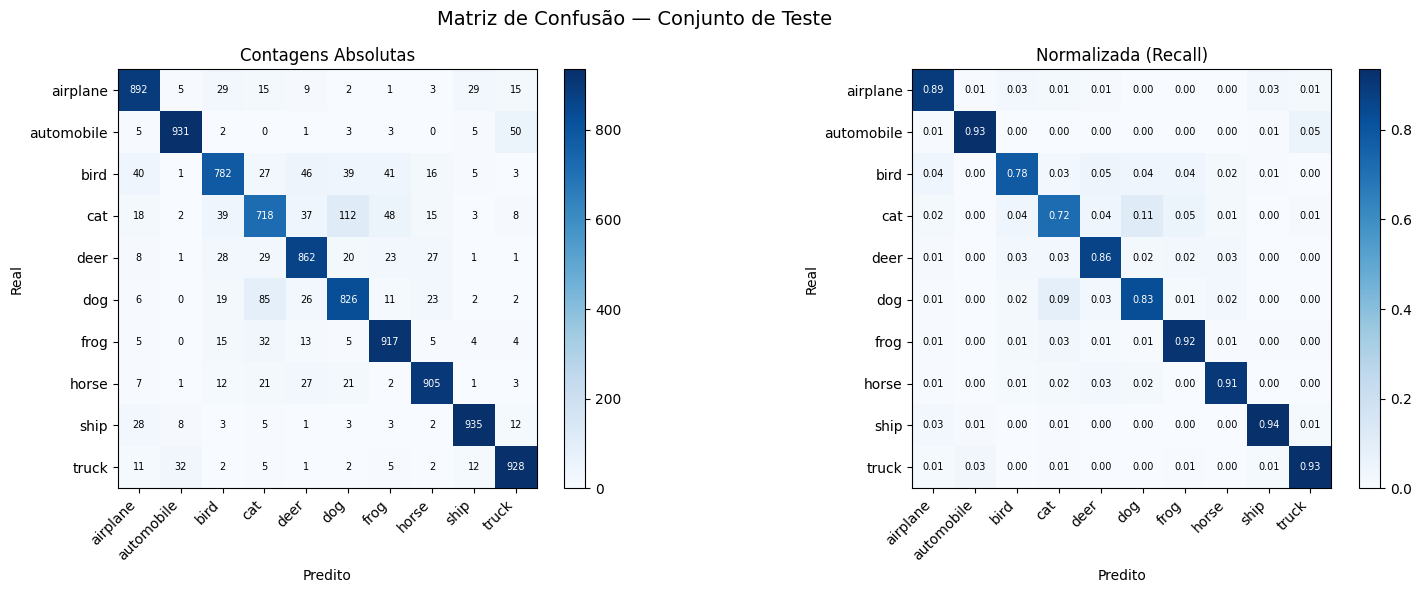


Acurácia por classe:
-----------------------------------
  airplane    :  89.20%
  automobile  :  93.10%
  bird        :  78.20%
  cat         :  71.80%
  deer        :  86.20%
  dog         :  82.60%
  frog        :  91.70%
  horse       :  90.50%
  ship        :  93.50%
  truck       :  92.80%

  GERAL       :  86.96%


In [8]:
from tqdm.notebook import tqdm

# Coleta todas as predições
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y_batch.numpy())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# ── Matriz de Confusão (manual, sem sklearn) ────────────────────────────────
n_classes = 10
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(all_labels, all_preds):
    conf_matrix[true][pred] += 1

# Normalizada por linha (recall por classe)
conf_matrix_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Matriz de Confusão — Conjunto de Teste", fontsize=14)

for ax, data, title, fmt in [
        (axes[0], conf_matrix,      "Contagens Absolutas", 'd'),
        (axes[1], conf_matrix_norm, "Normalizada (Recall)", '.2f')]:
    im = ax.imshow(data, cmap='Blues')
    ax.set_xticks(range(n_classes)); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
    ax.set_yticks(range(n_classes)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predito"); ax.set_ylabel("Real")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(n_classes):
        for j in range(n_classes):
            val = data[i, j]
            color = 'white' if (data[i, j] > data.max() * 0.6) else 'black'
            ax.text(j, i, format(val, fmt), ha='center', va='center',
                    fontsize=7, color=color)

plt.tight_layout()
plt.show()

# ── Acurácia por classe ─────────────────────────────────────────────────────
print("\nAcurácia por classe:")
print("-" * 35)
for i, cls in enumerate(CLASSES):
    acc = conf_matrix_norm[i, i] * 100
    print(f"  {cls:<12}: {acc:>6.2f}%")

overall_acc = np.trace(conf_matrix) / conf_matrix.sum() * 100
print(f"\n  {'GERAL':<12}: {overall_acc:>6.2f}%")

## 8. Visualização das Predições

Amostras do conjunto de teste com a predição do modelo (verde = correto, vermelho = errado).

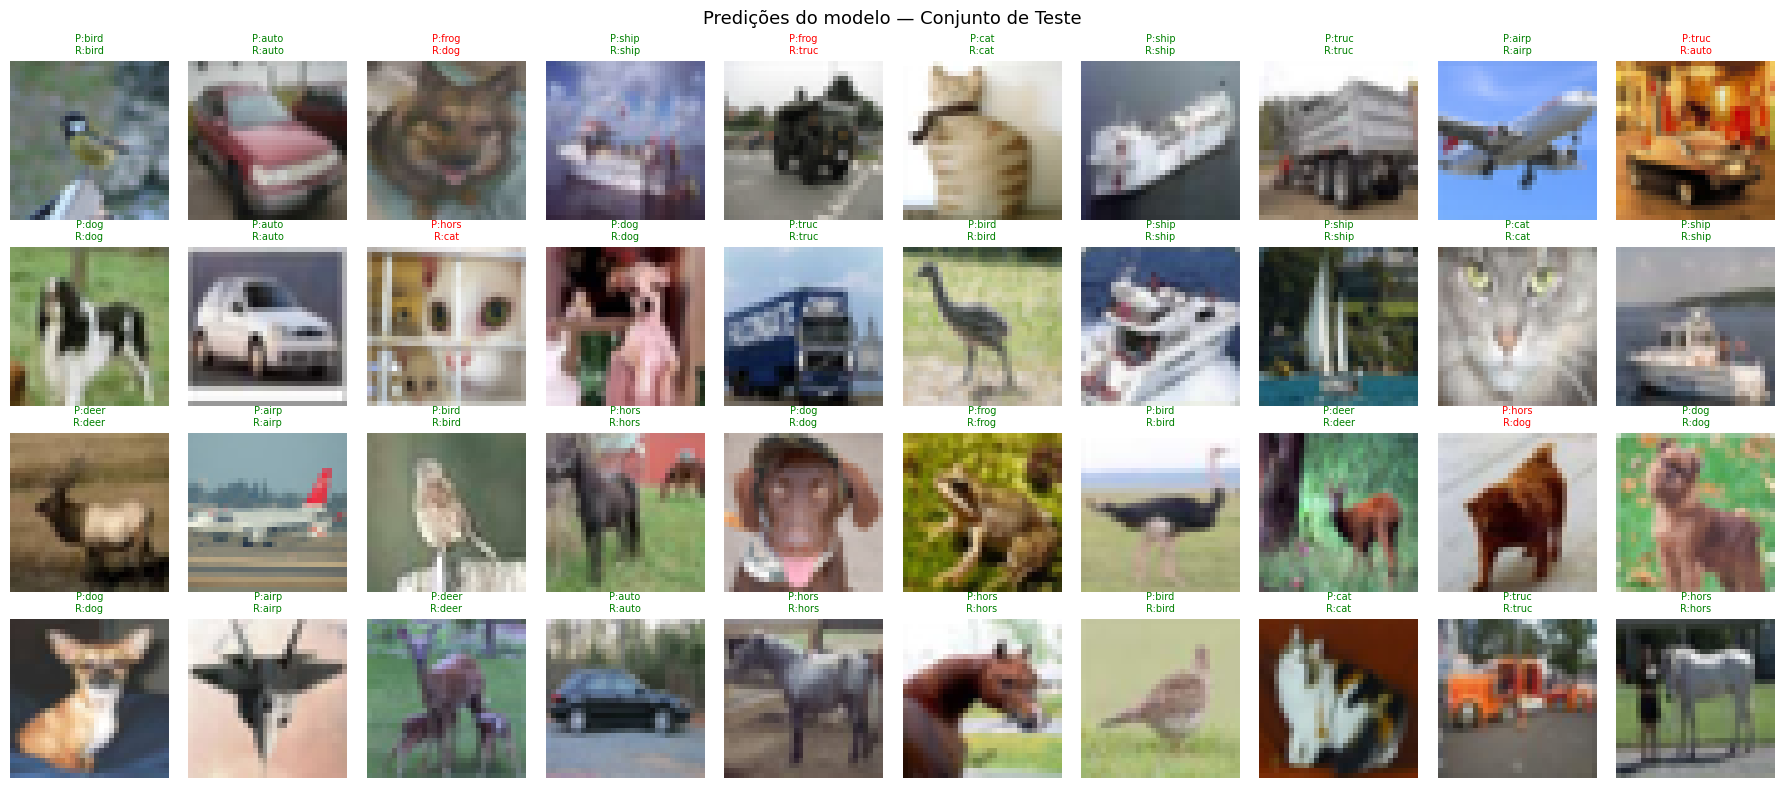

Modelo salvo em: cifar10_cnn.pth


In [9]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), 40, replace=False)

fig, axes = plt.subplots(4, 10, figsize=(18, 8))
fig.suptitle("Predições do modelo — Conjunto de Teste", fontsize=13)

for ax, idx in zip(axes.flatten(), sample_idx):
    true_label = y_test[idx]
    pred_label = all_preds[idx]
    img = X_test[idx].transpose(1, 2, 0).astype(np.uint8)
    ax.imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"P:{CLASSES[pred_label][:4]}\nR:{CLASSES[true_label][:4]}",
                 fontsize=7, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── Salvar o modelo ──────────────────────────────────────────────────────────
torch.save(model.state_dict(), "cifar10_cnn.pth")
print("Modelo salvo em: cifar10_cnn.pth")

## 9. Curva do Erro Médio

A **taxa de erro** ($1 - \text{acurácia}$) ao longo do treinamento evidencia a redução do erro do modelo a cada época, tanto no conjunto de treino quanto no de validação.

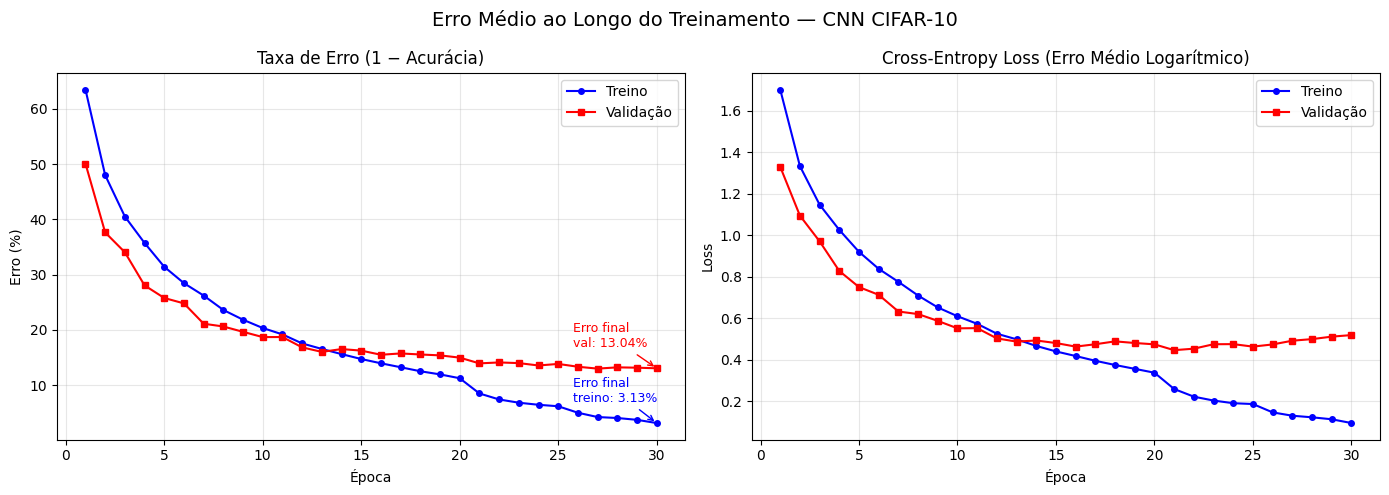

       RESUMO DO MODELO — CIFAR-10 CNN
  Épocas treinadas         : 30
  Acurácia final (treino)  : 96.87%
  Erro final    (treino)   : 3.13%
  Acurácia final (val)     : 86.96%
  Erro final    (val)      : 13.04%
  Melhor acurácia (val)    : 87.02%  (época 27)
  Menor erro    (val)      : 12.98%  (época 27)


In [11]:
train_error = [1 - a for a in history['train_acc']]
val_error   = [1 - a for a in history['val_acc']]
epochs_range = range(1, len(history['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Erro Médio ao Longo do Treinamento — CNN CIFAR-10", fontsize=14)

# ── Curva da taxa de erro ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_range, [e * 100 for e in train_error], 'b-o', markersize=4, label='Treino')
ax.plot(epochs_range, [e * 100 for e in val_error],   'r-s', markersize=4, label='Validação')
ax.set_title("Taxa de Erro (1 − Acurácia)")
ax.set_xlabel("Época")
ax.set_ylabel("Erro (%)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.annotate(f"Erro final\ntreino: {train_error[-1]*100:.2f}%",
            xy=(epochs_range[-1], train_error[-1]*100),
            xytext=(-60, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=9)
ax.annotate(f"Erro final\nval: {val_error[-1]*100:.2f}%",
            xy=(epochs_range[-1], val_error[-1]*100),
            xytext=(-60, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)

# ── Cross-Entropy Loss (erro médio absoluto de probabilidade) ────────────────
ax2 = axes[1]
ax2.plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Treino')
ax2.plot(epochs_range, history['val_loss'],   'r-s', markersize=4, label='Validação')
ax2.set_title("Cross-Entropy Loss (Erro Médio Logarítmico)")
ax2.set_xlabel("Época")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Resumo final ─────────────────────────────────────────────────────────────
print("=" * 45)
print("       RESUMO DO MODELO — CIFAR-10 CNN")
print("=" * 45)
print(f"  Épocas treinadas         : {len(history['train_acc'])}")
print(f"  Acurácia final (treino)  : {history['train_acc'][-1]*100:.2f}%")
print(f"  Erro final    (treino)   : {train_error[-1]*100:.2f}%")
print(f"  Acurácia final (val)     : {history['val_acc'][-1]*100:.2f}%")
print(f"  Erro final    (val)      : {val_error[-1]*100:.2f}%")
print(f"  Melhor acurácia (val)    : {max(history['val_acc'])*100:.2f}%  "
      f"(época {history['val_acc'].index(max(history['val_acc']))+1})")
print(f"  Menor erro    (val)      : {min(val_error)*100:.2f}%  "
      f"(época {val_error.index(min(val_error))+1})")
print("=" * 45)